In [1]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
plot_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.2],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [4]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [5]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_3_11_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [7]:
upper_bounds = [0.1, 0.2, 0.3]

optimizations = []
for u in upper_bounds:
    param_bounds = {
        "fts": [0, 175],
        "t": [40, 125],
        "ampc": [0.01, u],
        'ampm': [0,3],
        "ampg": [0.1, 4],
        "ampw": [0.01,0.08],
        "d": [10, 40],
        "inh_d": [0, 40],
        "inh_w": [0, 3],
    }

    dLGN_params = optimized_model['scaled_param_history']['dLGN_params'][:,-1]

    model = SGCCircuit(param_bounds)
    model.initialize_random_parameters(n_v1=2,n_lgn=3,n_sample=1000)
    model.update_transform()

    dLGN_params[:,:,:,2,:,:] = model.dlgn_raw[:,:,:,2,:,:].numpy()

    params = {
        'dLGN_params': dLGN_params,
        'V1_params': optimized_model['scaled_param_history']['V1_params'][:,-1]
    }

    # apply a jitter
    p = {x[0]:x[1] + tf.random.uniform(x[1].shape, -0.75, 0.75) 
        for x in params.items()}
    
    model = SGCCircuit(param_bounds)
    model.load_saved_parameters(p)

    # initialize the optimizer
    optimizer = Optimize(model, epochs=2000, loss_threshold=0)

    # fit the model
    loss_decay = optimizer.fit(X, Y_true)
    optimizer.save_state(f'conditional_optimization_ampc_upper_{u}')
    optimizations.append(optimizer)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000001D34ABD7370>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.14146345853805542
med_loss = 0.6451988816261292
max_loss = 2.776017904281616

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.09705709666013718
med_loss = 0.3936745822429657
max_loss = 1.8118599653244019

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.08905632048845291
med_loss = 0.26322290301322937
max_loss = 1.2115886211395264

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.08505597710609436
med_loss = 0.19597980380058289
max_loss = 0.8324551582336426

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.08006739616394043
med_loss = 0.1572813093662262
max_loss = 0.5894737839698792

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.07605625689029694
med_loss = 0.1341570019721985
max_loss = 0.43280306458473206

Training step = 600, N_exploration_samples =

Text(0, 0.5, 'Loss (MSE)')

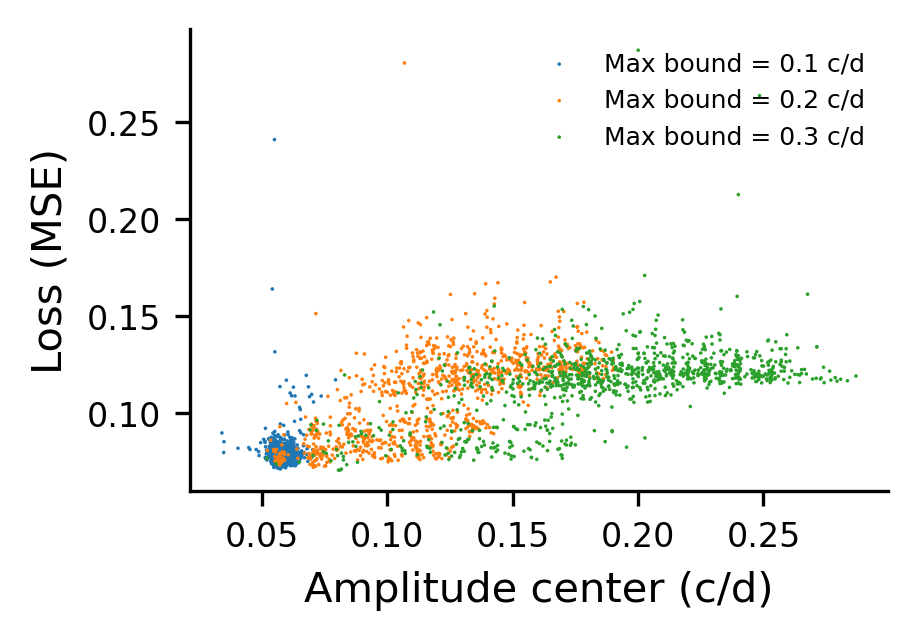

In [8]:
fig, ax = plt.subplots(figsize = (3,2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)
thresh = 0.08
under_thresh = []
for i in range(3):
    x = optimizations[i].outputs['param_history']['dLGN_params'][:,-1][:,:,:,2,0,0].mean((1,2))
    y = optimizations[i].outputs['loss_decay'][-1]
    under_thresh.append(len(np.where(y<thresh)[0]))
    ax.scatter(x,y, label = f"Max bound = {upper_bounds[i]} c/d", s = 0.75, edgecolors='none')
ax.legend(fontsize = 6, frameon = False)
ax.set_xlabel("Amplitude center (c/d)")
#ax.set_ylim(0.05,0.2)
ax.set_ylabel("Loss (MSE)")

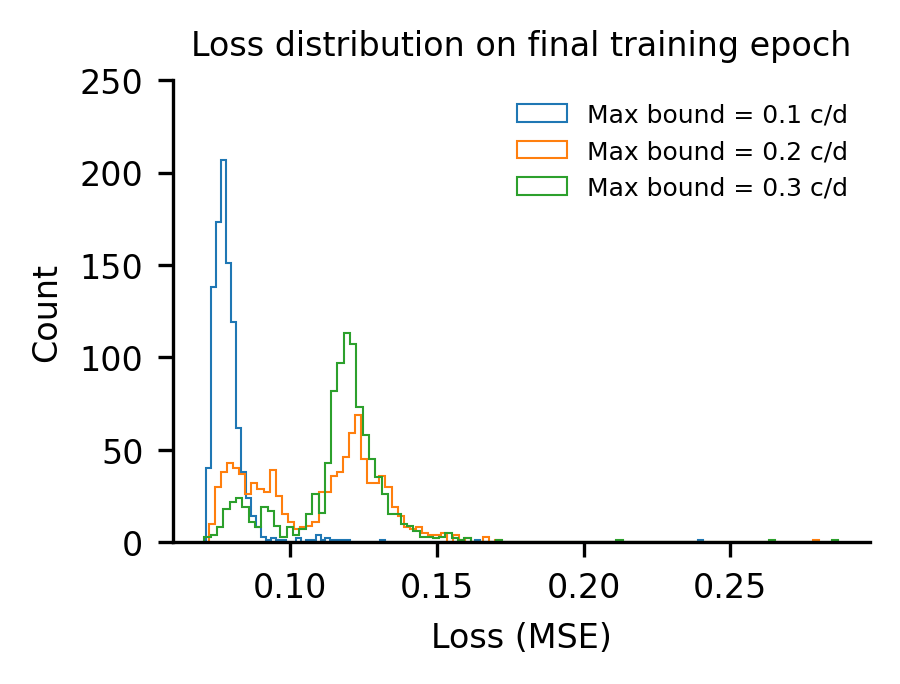

In [9]:
fig, ax = plt.subplots(figsize = (3,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_ylim(0,250)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
for i in range(3):
    y = optimizations[i].outputs['loss_decay'][-1]
    ax.hist(y, bins = 100, label = f"Max bound = {upper_bounds[i]} c/d", histtype='step', linewidth = 0.5)

ax.legend(fontsize = 6, frameon = False)

Text(0, 0.5, 'Number of solutions with MSE < 0.08')

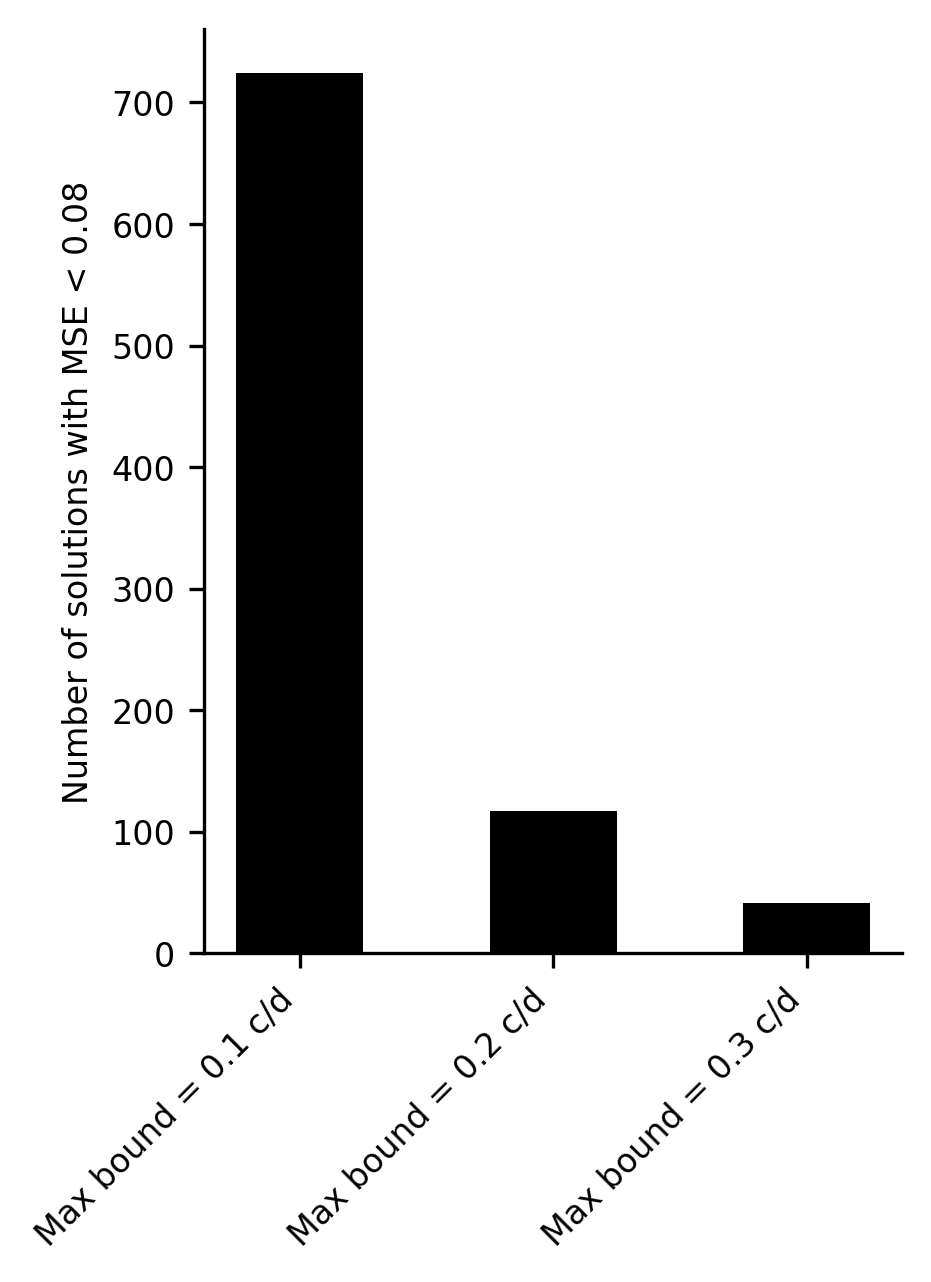

In [10]:
fig, ax = plt.subplots(figsize = (3,4))
labels = [
    f"Max bound = {x} c/d"
    for x in upper_bounds
]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)
ax.bar(labels, under_thresh, color = 'black', width = 0.5)
ax.set_xticks(np.arange(3))
ax.set_xticklabels(labels, rotation = 45, ha = 'right', fontsize = 8)
ax.set_ylabel("Number of solutions with MSE < 0.08", fontsize = 8)

In [11]:
loss_selection = optimizations[1].outputs['loss_decay'][-1]
ind = np.where(
    np.logical_and(
        loss_selection<0.1,
        loss_selection>0.085
    )
)[0]

In [12]:
param_history = {
    x[0]:x[1][ind] 
    for x in optimizations[1].outputs['param_history'].items()
}

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

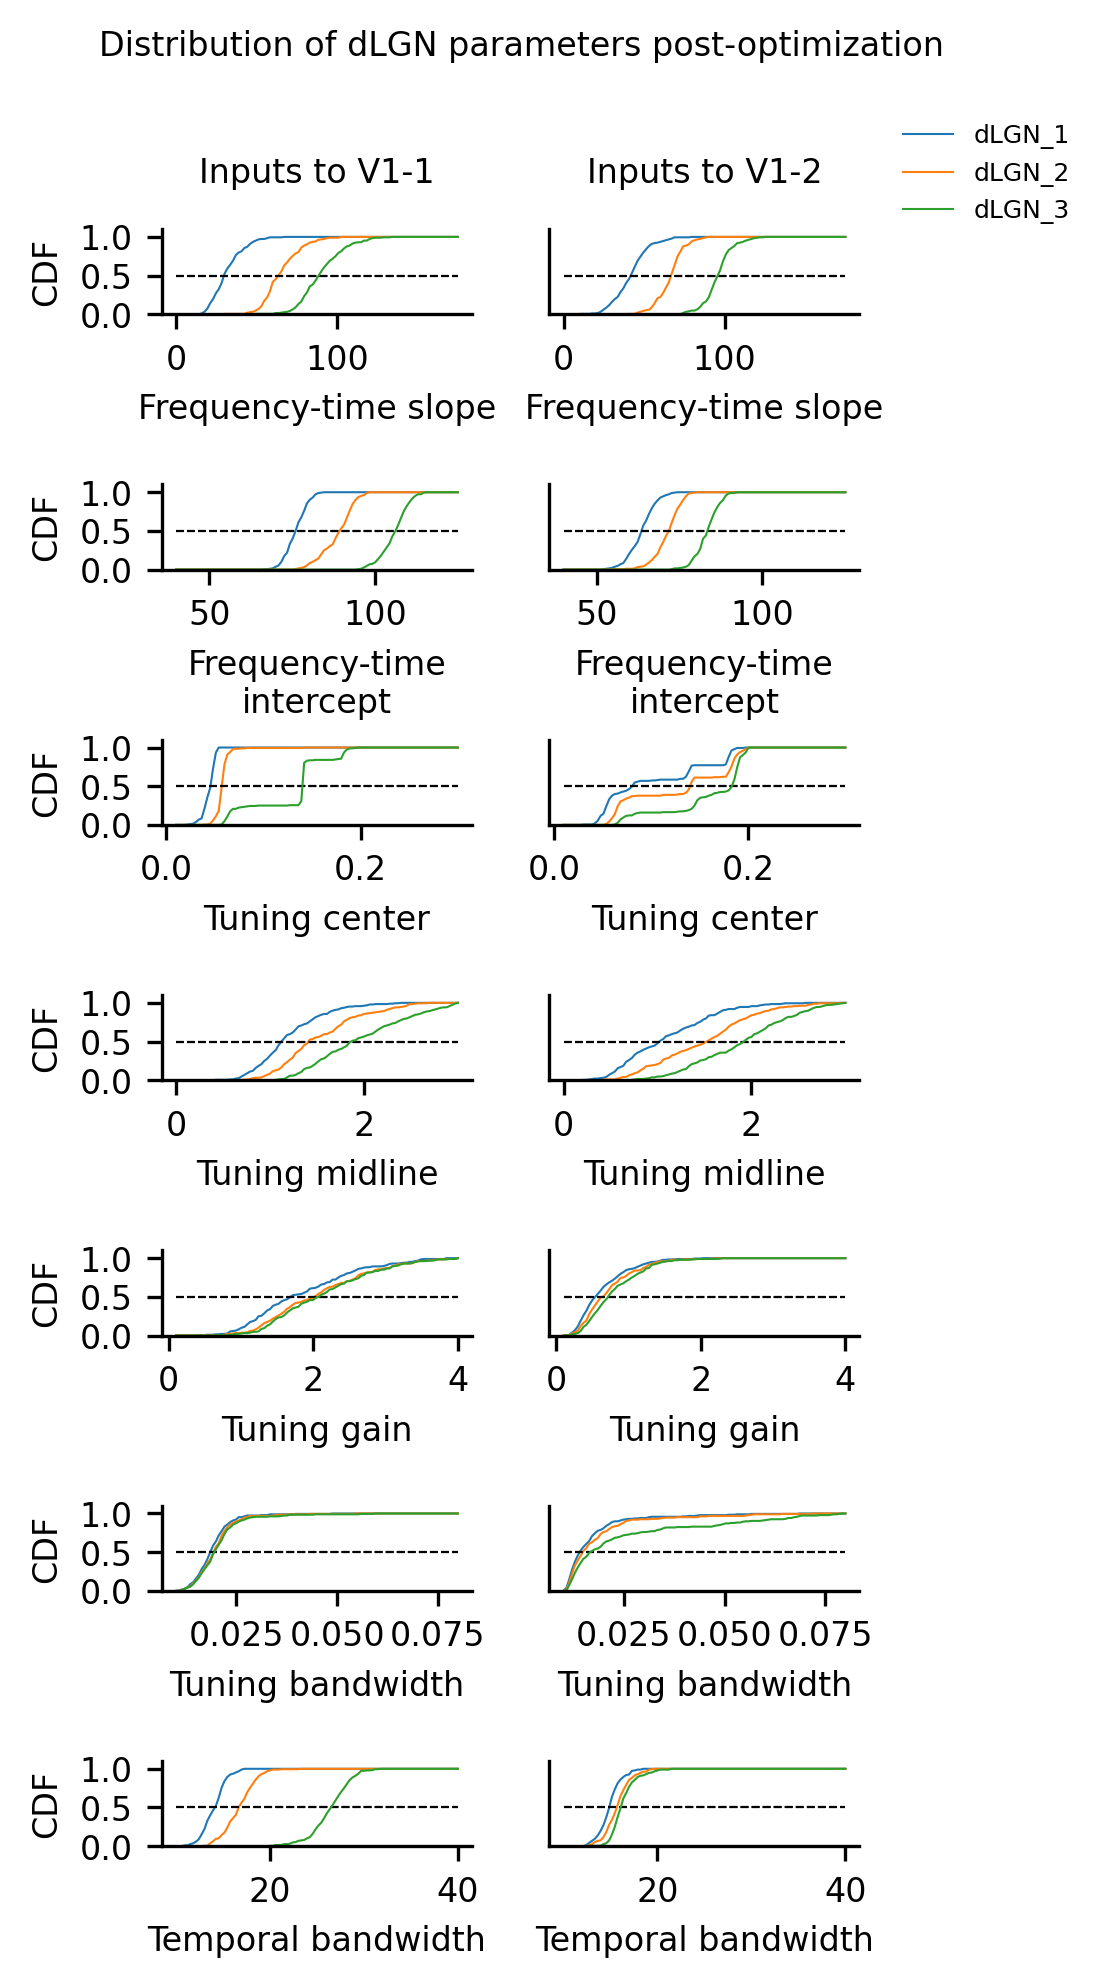

In [13]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(data).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)